# kNN Imputation Overview

Backup research:
- https://pmc.ncbi.nlm.nih.gov/articles/PMC10870437/#Sec15
- http://www.csam.or.kr/journal/view.html?doi=10.29220/CSAM.2023.30.3.331

# Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, recall_score, roc_curve
from sklearn.svm import SVC
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
import joblib
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt



# Import Heart Attack / Disease Data

In [3]:
import os
print(os.getcwd())

/Users/shistatabagale/Downloads


In [4]:
# load data
heart_data = pd.read_csv('../Heart_Attack_data.csv')
print(heart_data.head())

   HeartDiseaseorAttack  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0                   0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1                   0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2                   0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3                   0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4                   0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   Diabetes  PhysActivity  Fruits  ...  AnyHealthcare  NoDocbcCost  GenHlth  \
0       0.0           0.0     0.0  ...            1.0          0.0      5.0   
1       0.0           1.0     0.0  ...            0.0          1.0      3.0   
2       0.0           0.0     1.0  ...            1.0          1.0      5.0   
3       0.0           1.0     1.0  ...            1.0          0.0      2.0   
4       0.0           1.0     1.0  ...            1.0          0.0      2.0   

   MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  I

# Step 1: Determine optimal k using imblearn pipeline

Training:Test split was 0.95:0.05; among 0.95, 5% of the training data was used to train for efficiency.

/Users/shistatabagale/anaconda3/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


k=1
k=3
k=5
k=7
k=9
k=11
k=13
k=15
k=17
k=19
k=21
k=23
k=25

Optimal k value: 25

MSE: 0.8612


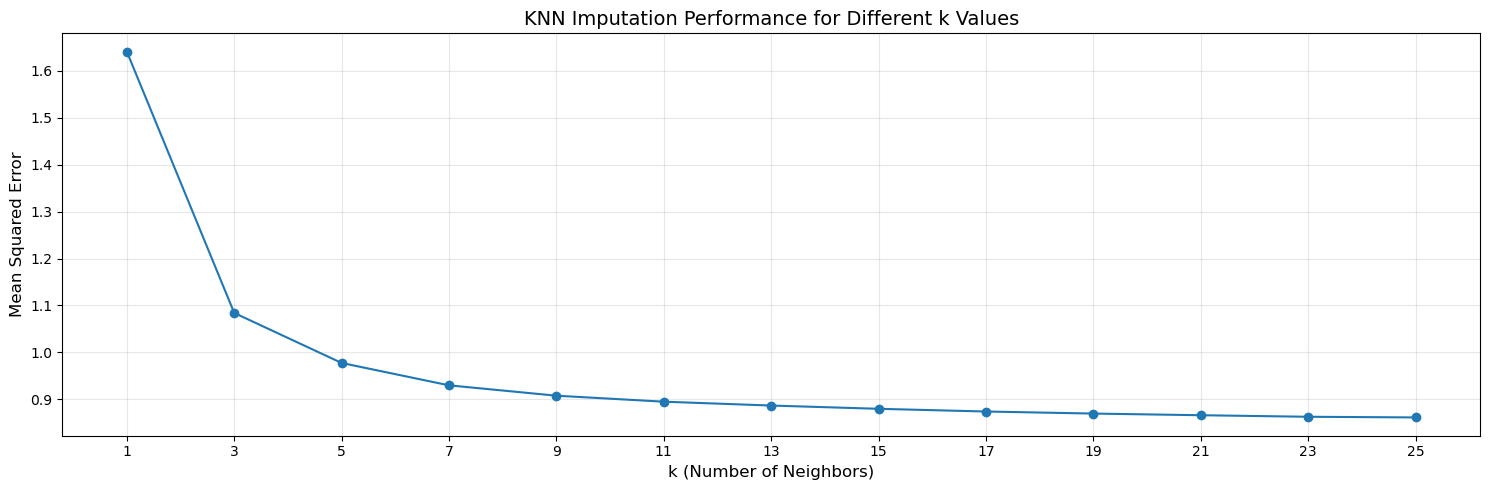

In [5]:
# 15% missing values on 5% of data
# 3 for team 3 :)
def evaluate_knn_imputation(data, k_values, test_size=0.05, random_state=3):
    data_copy = data.copy()
    
    # train/test split
    train_data, test_data = train_test_split(data_copy, test_size=test_size, random_state=random_state)

    # randomly set approx 15% of values to NaN
    test_missing = test_data.copy()
    mask = np.random.rand(*test_missing.shape) < 0.15
    original_values = test_missing.values.copy()
    test_missing = test_missing.mask(mask)

    # 5% of data for training
    train_data = train_data.sample(frac=0.05, random_state=random_state)

    # add scaler before imputation
    scaler = StandardScaler()
    train_data = pd.DataFrame(scaler.fit_transform(train_data), columns=train_data.columns)
    test_missing_values = test_missing.fillna(0)
    test_missing_scaled = pd.DataFrame(scaler.transform(test_missing_values), columns=test_missing.columns)
    test_missing_scaled = test_missing_scaled.mask(mask)
    original_values_scaled = scaler.transform(original_values)

    results = {}
    
    for k in k_values:
        print(f"k={k}")
        imputer = KNNImputer(n_neighbors=k)
        imputer.fit(train_data)
        
        # impute missing values in test data
        imputed_values = imputer.transform(test_missing_scaled)
        
        # calculate mean squared error compared to actual values
        mse = np.mean(((imputed_values[mask] - original_values_scaled[mask]) ** 2))
        results[k] = mse    

    return results

k_values = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
results = evaluate_knn_imputation(heart_data, k_values)

# k with lowest MSE
optimal_k = min(results, key=results.get)
print(f"\nOptimal k value: {optimal_k}")
print(f"\nMSE: {results[optimal_k]:.4f}")

# Plot results
plt.figure(figsize=(15, 5))
plt.plot(list(results.keys()), list(results.values()), marker='o', linestyle='-')
plt.xlabel('k (Number of Neighbors)', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('KNN Imputation Performance for Different k Values', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)

plt.tight_layout()
plt.show()

/Users/shistatabagale/anaconda3/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


k=1
k=3
k=5
k=7
k=9
k=11
k=13
k=15
k=17
k=19
k=21
k=23
k=25

Optimal k value: 25

MSE: 0.9030


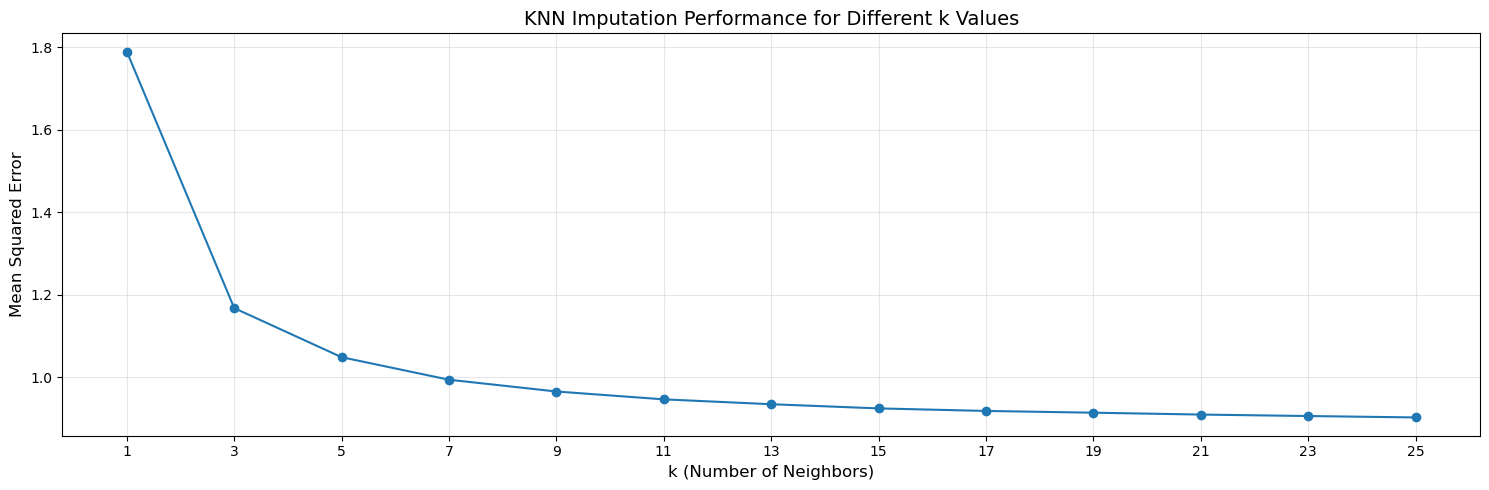

In [7]:
# 50% missing values on 5% of data
def evaluate_knn_imputation(data, k_values, test_size=0.05, random_state=3):
    data_copy = data.copy()
    
    # train/test split
    train_data, test_data = train_test_split(data_copy, test_size=test_size, random_state=random_state)

    # randomly set approx 15% of values to NaN
    test_missing = test_data.copy()
    mask = np.random.rand(*test_missing.shape) < 0.5
    original_values = test_missing.values.copy()
    test_missing = test_missing.mask(mask)

    # 5% of data for training
    train_data = train_data.sample(frac=0.05, random_state=random_state)

    # Add scaling before imputation
    scaler = StandardScaler()
    train_data = pd.DataFrame(scaler.fit_transform(train_data), columns=train_data.columns)
    test_missing_values = test_missing.fillna(0)
    test_missing_scaled = pd.DataFrame(scaler.transform(test_missing_values), columns=test_missing.columns)
    test_missing_scaled = test_missing_scaled.mask(mask)
    original_values_scaled = scaler.transform(original_values)

    results = {}
    
    for k in k_values:
        print(f"k={k}")
        imputer = KNNImputer(n_neighbors=k)
        imputer.fit(train_data)
        
        # impute missing values in test data
        imputed_values = imputer.transform(test_missing_scaled)
        
        # calculate mean squared error compared to actual values
        mse = np.mean(((imputed_values[mask] - original_values_scaled[mask]) ** 2))
        results[k] = mse    

    return results

k_values = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
results = evaluate_knn_imputation(heart_data, k_values)

# k with lowest MSE
optimal_k = min(results, key=results.get)
print(f"\nOptimal k value: {optimal_k}")
print(f"\nMSE: {results[optimal_k]:.4f}")

# Plot results
plt.figure(figsize=(15, 5))
plt.plot(list(results.keys()), list(results.values()), marker='o', linestyle='-')
plt.xlabel('k (Number of Neighbors)', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('KNN Imputation Performance for Different k Values', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)

plt.tight_layout()
plt.show()

In [8]:
# Attempting to train on all 250k+ inputs, using k = 500
# Follows general rule of sqrt(N)/2, where N is number of inputs --> sqrt(250k)/2 = 250
# 50% missing values on 5% of data
def evaluate_knn_imputation(data, k_values, test_size=0.05, random_state=3):
    data_copy = data.copy()
    
    # train/test split
    train_data, test_data = train_test_split(data_copy, test_size=test_size, random_state=random_state)

    # randomly set approx 15% of values to NaN
    test_missing = test_data.copy()
    mask = np.random.rand(*test_missing.shape) < 0.5
    original_values = test_missing.values.copy()
    test_missing = test_missing.mask(mask)

    # Add scaling before imputation
    scaler = StandardScaler()
    train_data = pd.DataFrame(scaler.fit_transform(train_data), columns=train_data.columns)
    test_missing_values = test_missing.fillna(0)
    test_missing_scaled = pd.DataFrame(scaler.transform(test_missing_values), columns=test_missing.columns)
    test_missing_scaled = test_missing_scaled.mask(mask)
    original_values_scaled = scaler.transform(original_values)

    results = {}
    
    for k in k_values:
        print(f"k={k}")
        imputer = KNNImputer(n_neighbors=k)
        imputer.fit(train_data)
        
        # impute missing values in test data
        imputed_values = imputer.transform(test_missing_scaled)
        
        # calculate mean squared error compared to actual values
        mse = np.mean(((imputed_values[mask] - original_values_scaled[mask]) ** 2))
        results[k] = mse    

    return results

k_values = [250]
results = evaluate_knn_imputation(heart_data, k_values)

# k = 250 results
print(f"\nMSE: {results[250]:.4f}")

k=250


/Users/shistatabagale/anaconda3/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



MSE: 0.8797


# Step 2: Train final imputation algorithm run using optimal k

In [9]:
def train_imputation_model(data_path, k=250):
    heart_data = pd.read_csv(data_path)
    
    # drop target var
    features = heart_data.drop('HeartDiseaseorAttack', axis=1)
    
    imputation_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn_imputer', KNNImputer(n_neighbors=k)),
    ])
    
    imputation_pipeline.fit(features)
    
    return imputation_pipeline


In [10]:
# test user data
def user_data_row(
    high_bp=0,                
    high_chol=0,             
    chol_check=0,              
    smoker=0,              
    stroke=0,                   
    phys_activity=0,          
    fruits=0,               
    veggies=0,                 
    hvy_alcohol_consump=0,      
    any_healthcare=0,          
    no_doc_bc_cost=0,          
    diff_walk=0,               
    sex=0,
    bmi=25.0,
    ment_hlth=0,                
    phys_hlth=0,
    diabetes=0,             
    gen_hlth=0,                
    age=0,                     
    education=0,               
    income=0                   
):
    data = {
        'HighBP': high_bp,
        'HighChol': high_chol,
        'CholCheck': chol_check,
        'BMI': bmi,
        'Smoker': smoker,
        'Stroke': stroke,
        'Diabetes': diabetes,
        'PhysActivity': phys_activity,
        'Fruits': fruits,
        'Veggies': veggies,
        'HvyAlcoholConsump': hvy_alcohol_consump,
        'AnyHealthcare': any_healthcare,
        'NoDocbcCost': no_doc_bc_cost,
        'GenHlth': gen_hlth,
        'MentHlth': ment_hlth,
        'PhysHlth': phys_hlth,
        'DiffWalk': diff_walk,
        'Sex': sex,
        'Age': age,
        'Education': education,
        'Income': income
    }
    
    # Create a DataFrame with a single row
    return pd.DataFrame([data])

# test_user_data = user_data_row(high_bp=0, high_chol=0, chol_check=1, smoker=0, stroke=0,
#                                phys_activity=np.nan, fruits=1, veggies=1, hvy_alcohol_consump=0,
#                                any_healthcare=1, no_doc_bc_cost=0, diff_walk=0, bmi=np.nan, diabetes=0,
#                                gen_hlth=5, ment_hlth=np.nan, phys_hlth=np.nan, sex=1, age=np.nan, education=4, income=5)

test_user_data = user_data_row(
        high_bp=1,
        high_chol=1,
        chol_check=1,
        smoker=1,
        stroke=1,
        phys_activity=0,
        fruits=1,
        veggies=0,
        hvy_alcohol_consump=1,
        any_healthcare=1,
        no_doc_bc_cost=0,
        diff_walk=0,
        bmi=40,
        diabetes=0,
        gen_hlth=2,
        ment_hlth=np.nan,
        phys_hlth=np.nan,
        sex=1,
        age=np.nan,
        education=3,
        income=4
    )


In [11]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [14]:
# function to impute user data
def impute_data(data, imputation_pipeline, binary_cols, categorical_cols, numeric_cols):
    original_data = data.copy()
    nan_mask = original_data.isna()
    
    # return original data if no nan values
    if not nan_mask.any().any():
        return original_data
    
    data = data.astype(float)
    
    scaled_imputed_values = imputation_pipeline.transform(data)
    scaler = imputation_pipeline.named_steps['scaler']
    imputed_values = scaler.inverse_transform(scaled_imputed_values)
    imputed_df = pd.DataFrame(imputed_values, columns=data.columns)
    
    for col in original_data.columns:
        if nan_mask[col].any():
            if col in binary_cols:
                # round to nearest integer and clip to 0 or 1 for binary
                original_data.loc[nan_mask[col], col] = np.round(imputed_df.loc[nan_mask[col], col]).clip(0, 1).astype(int)
            elif col in categorical_cols:
                # round to nearest integer for categorical  
                original_data.loc[nan_mask[col], col] = np.round(imputed_df.loc[nan_mask[col], col]).astype(int)
            elif col in numeric_cols:
                # also round to nearest integer for numeric
                original_data.loc[nan_mask[col], col] = np.round(imputed_df.loc[nan_mask[col], col]).astype(int)
    
    # Print which values were imputed
    imputed_cols = [col for col in original_data.columns if nan_mask[col].any()]
    print(f"Imputed values for columns: {imputed_cols}")
    
    return original_data

 # Define column types
binary_cols = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 
                'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump',
                'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
categorical_cols = ['Diabetes', 'GenHlth', 'Age', 'Education', 'Income']
numeric_cols = ['BMI', 'MentHlth', 'PhysHlth']

data_path = "../Heart_Attack_data.csv"

imputation_pipeline = train_imputation_model(data_path, k=250)

# Run:
imputed_user_data = impute_data(test_user_data, imputation_pipeline, binary_cols, categorical_cols, numeric_cols)
print(imputed_user_data)

Imputed values for columns: ['MentHlth', 'PhysHlth', 'Age']
   HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  Diabetes  PhysActivity  \
0       1         1          1   40       1       1         0             0   

   Fruits  Veggies  HvyAlcoholConsump  AnyHealthcare  NoDocbcCost  GenHlth  \
0       1        0                  1              1            0        2   

   MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  Income  
0       4.0       5.0         0    1  10.0          3       4  
